170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Training shape: (50000, 32, 32, 3)
Testing shape: (10000, 32, 32, 3)


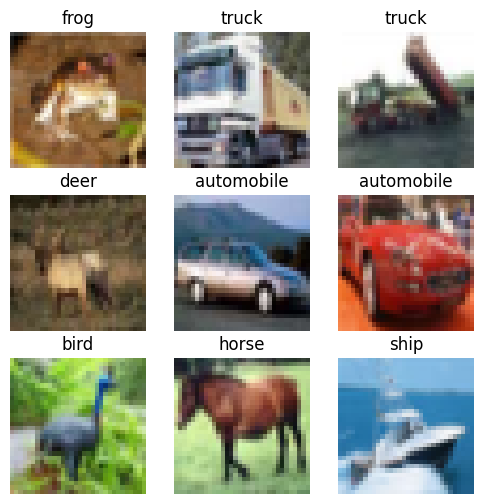

In [ ]:
import tensorflow as tf         # Import Libraries
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.layers import Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator


(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print("Training shape:", x_train.shape)
print("Testing shape:", x_test.shape)


x_train = x_train / 255.0    # Normalize the images
x_test = x_test / 255.0

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

plt.figure(figsize=(6,6))      # Visualize sample images

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')

plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 177s 223ms/step - accuracy: 0.3669 - loss: 1.7258 - val_accuracy: 0.4988 - val_loss: 1.3759
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 181s 231ms/step - accuracy: 0.4983 - loss: 1.3818 - val_accuracy: 0.5609 - val_loss: 1.2310
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 179s 229ms/step - accuracy: 0.5693 - loss: 1.2213 - val_accuracy: 0.6455 - val_loss: 0.9864
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 171s 219ms/step - accuracy: 0.6109 - loss: 1.1152 - val_accuracy: 0.6723 - val_loss: 0.9201
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 173s 221ms/step - accuracy: 0.6373 - loss: 1.0438 - val_accuracy: 0.5966 - val_loss: 1.2713
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 170s 218ms/step - accuracy: 0.6567 - loss: 0.9900 - val_accuracy: 0.6761 - val_loss: 0.9282
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 174s 222ms/step - accuracy: 0.6746 - loss: 0.9416 - val_accuracy: 0.6933 - val_loss: 0.8997
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 202s 222ms/step - accuracy: 0.6856 -

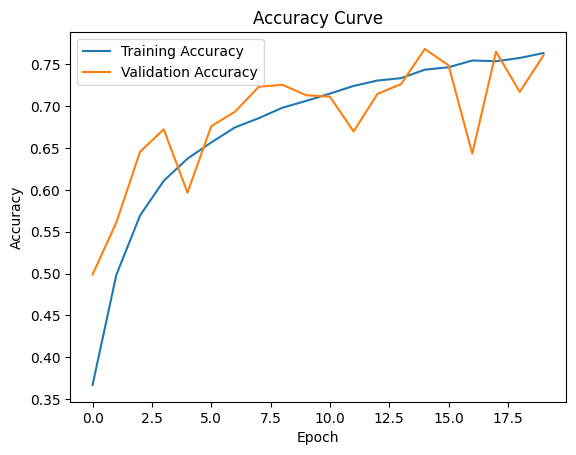

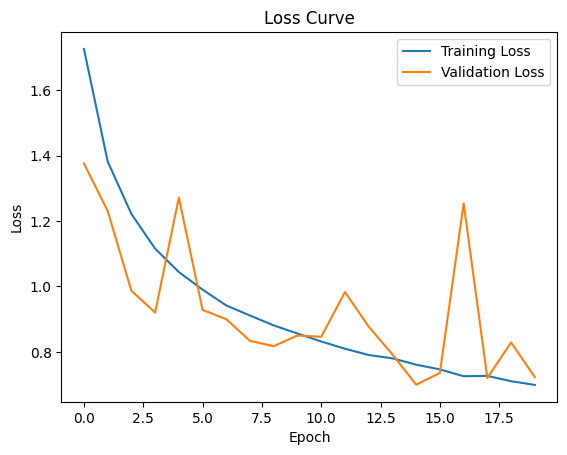

In [ ]:
datagen = ImageDataGenerator(             # Data Augmentation
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

datagen.fit(x_train)


model = Sequential()       #Build CNN Model (LeNet - Style)

# Convolution Layer
model.add(Conv2D(32, (3,3), padding='same', activation='relu', input_shape=(32,32,3)))
model.add(BatchNormalization())

# Pooling
model.add(MaxPooling2D((2,2)))

# Second Convolution
model.add(Conv2D(64, (3,3), padding='same', activation='relu'))
model.add(BatchNormalization())

model.add(MaxPooling2D((2,2)))

# Third Convolution
model.add(Conv2D(128, (3,3), padding='same', activation='relu'))

model.add(MaxPooling2D((2,2)))

# Flatten
model.add(Flatten())

# Fully Connected Layer
model.add(Dense(128, activation='relu'))

# Dropout
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(10, activation='softmax'))

model.compile(      # Compile the model
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


history = model.fit(       # Train the Model
    datagen.flow(x_train, y_train, batch_size=64),
    epochs=20,
    validation_data=(x_test, y_test)
)

test_loss, test_acc = model.evaluate(x_test, y_test)      # Evaluate Model

print("Test Accuracy:", test_acc)

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Accuracy Curve")

plt.show()


plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss Curve")

plt.show()